In [29]:
import numpy as np
import pandas as pd
import mne

In [120]:
eeg_df = pd.read_csv("offline_2back_sham.csv")
eeg_df

,Time,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08
0,0.000,-43745.968750,-90054.648438,-96530.523438,2154.469971,-90810.164062,-44963.605469,-43845.519531,-97578.898438
1,0.004,-45293.335938,-89654.046875,-96594.414062,1629.781860,-90186.773438,-46047.710938,-45723.730469,-97458.750000
2,0.008,-46425.656250,-90015.875000,-96968.726562,1299.262329,-90561.851562,-46726.898438,-46250.636719,-97556.335938
3,0.012,-44949.582031,-90330.125000,-96877.984375,1767.635498,-91075.812500,-45698.292969,-44528.730469,-97683.546875
4,0.016,-43675.398438,-90129.226562,-96554.187500,2179.026855,-90943.046875,-44899.230469,-43664.863281,-97593.148438
...,...,...,...,...,...,...,...,...,...
49740,198.960,-60765.843750,-102492.601562,-111593.539062,-15888.333984,-105135.234375,-59842.738281,-59195.761719,-123742.335938
49741,198.964,-60548.886719,-102734.859375,-111708.984375,-15843.250000,-105367.562500,-59828.687500,-59246.167969,-123918.101562
49742,198.968,-60606.648438,-101624.109375,-111095.851562,-15986.396484,-103994.960938,-59968.957031,-60424.593750,-124026.187500
49743,198.972,-60808.875000,-101210.960938,-110888.273438,-16054.989258,-103558.046875,-60003.781250,-60565.480469,-123888.773438


In [121]:
markers = pd.read_csv("lifu_markers_1_2back_sham.csv")
markers

,Time,marker,LSL_timestamp
0,2.837794,collecting_baseline,898814.006024
1,2.881106,collecting_baseline,898814.049337
2,2.915404,collecting_baseline,898814.083635
3,2.955411,collecting_baseline,898814.123641
4,3.001157,collecting_baseline,898814.169387
...,...,...,...
213,160.207192,LIFU_OFF,898971.375423
214,175.694626,LIFU_ON,898986.862856
215,180.698359,LIFU_OFF,898991.866589
216,191.404014,LIFU_ON,899002.572245


In [122]:

psychopy = pd.read_csv('C:\\Users\\jshin\\OW_closedloopLIFU\\n-back-task-with-visual-stimuli\\data\\sham_untitled_2026-06-23_10h03.09.092.csv')
psychopy

,location,corrAns,thisN,thisTrialN,thisRepN,response_2.keys,response_2.corr,response_2.rt,response_2.duration,trials.thisRepN,...,trials.response_2.duration,participant,session,date,expName,expVersion,psychopyVersion,frameRate,expStart,Unnamed: 51
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,sham,1.0,2026-06-23_10h05.11.694,untitled,NaN,2026.1.3,128.280452,2026-06-23 10h05.12.120590 -0700,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,sham,1.0,2026-06-23_10h05.11.694,untitled,NaN,2026.1.3,128.280452,2026-06-23 10h05.12.120590 -0700,NaN
2,"[0, 0]",NaN,0.0,0.0,0.0,NaN,1.0,NaN,NaN,0.0,...,NaN,sham,1.0,2026-06-23_10h05.11.694,untitled,NaN,2026.1.3,128.280452,2026-06-23 10h05.12.120590 -0700,NaN
3,"[0.2, 0]",NaN,1.0,1.0,0.0,NaN,1.0,NaN,NaN,0.0,...,NaN,sham,1.0,2026-06-23_10h05.11.694,untitled,NaN,2026.1.3,128.280452,2026-06-23 10h05.12.120590 -0700,NaN
4,"[0, 0]",space,2.0,2.0,0.0,space,1.0,0.587212,0.112276,0.0,...,0.112276,sham,1.0,2026-06-23_10h05.11.694,untitled,NaN,2026.1.3,128.280452,2026-06-23 10h05.12.120590 -0700,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,"[-0.2, 0]",space,61.0,61.0,0.0,NaN,0.0,NaN,NaN,0.0,...,NaN,sham,1.0,2026-06-23_10h05.11.694,untitled,NaN,2026.1.3,128.280452,2026-06-23 10h05.12.120590 -0700,NaN
64,"[0, 0]",NaN,62.0,62.0,0.0,NaN,1.0,NaN,NaN,0.0,...,NaN,sham,1.0,2026-06-23_10h05.11.694,untitled,NaN,2026.1.3,128.280452,2026-06-23 10h05.12.120590 -0700,NaN
65,"[0, -0.2]",NaN,63.0,63.0,0.0,NaN,1.0,NaN,NaN,0.0,...,NaN,sham,1.0,2026-06-23_10h05.11.694,untitled,NaN,2026.1.3,128.280452,2026-06-23 10h05.12.120590 -0700,NaN
66,"[0, 0.2]",NaN,64.0,64.0,0.0,NaN,1.0,NaN,NaN,0.0,...,NaN,sham,1.0,2026-06-23_10h05.11.694,untitled,NaN,2026.1.3,128.280452,2026-06-23 10h05.12.120590 -0700,NaN


In [123]:
psychopy_space = psychopy[psychopy['response_2.keys']=='space']
space_time_start = np.array(psychopy_space['LSL_Time'])
reaction_time = np.array(psychopy_space['trials.response_2.rt'])
space_time = space_time_start + reaction_time
space_time

array([898872.1762091, 898884.0053672, 898890.0080936, 898896.3242901,
       898898.3969885, 898910.3594137, 898922.2577604, 898928.3129672,
       898937.9476223, 898940.1409341, 898950.5089559, 898970.483208 ,
       898976.2189631, 898986.4206419])

In [124]:
start_time = 898868.2512194 - 57.08298870001454 # CALCULATE BY DOING LSL - NON LSL TIME

In [125]:
# windowing
# windowing scope eeg
pre = 0.2
post = 0.8
theta_windows = []
start_time = start_time # INSERT
space_time_onset = space_time - start_time

for idx, event in enumerate(space_time_onset): 
    mask = (eeg_df['Time'] >= (event - pre)) & (eeg_df['Time'] <= (event + post))
    window_df = eeg_df.loc[mask].copy()
    window_df["t_rel"] = window_df["Time"] - event 
    window_df["idx"] = idx
    theta_windows.append(window_df)

theta_windows[1]

,Time,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08,t_rel,idx
18160,72.640,13518.406250,-29400.615234,-36703.179688,75614.437500,-33480.269531,14697.411133,15546.083984,-94237.421875,-0.197137,1
18161,72.644,13770.367188,-29650.978516,-36823.394531,75684.171875,-33740.210938,14763.570312,15618.015625,-90332.625000,-0.193137,1
18162,72.648,13893.248047,-28662.208984,-36268.480469,75523.226562,-32488.396484,14677.192383,14546.325195,-94402.812500,-0.189137,1
18163,72.652,13638.591797,-28224.781250,-36043.792969,75444.296875,-32005.265625,14587.546875,14271.140625,-94113.210938,-0.185137,1
18164,72.656,13495.495117,-29186.396484,-36591.242188,75553.164062,-33213.781250,14665.414062,15317.442383,-90332.976562,-0.181137,1
...,...,...,...,...,...,...,...,...,...,...,...
18405,73.620,12619.638672,-29290.177734,-37114.718750,73860.351562,-33151.148438,13618.375000,13443.971680,-94257.375000,0.782863,1
18406,73.624,12518.359375,-30420.927734,-37750.343750,74024.023438,-34566.050781,13711.833984,14610.245117,-90078.101562,0.786863,1
18407,73.628,12813.521484,-30585.291016,-37827.425781,74053.539062,-34710.718750,13765.193359,14566.541992,-94235.187500,0.790863,1
18408,73.632,12874.200195,-29527.380859,-37228.492188,73911.734375,-33382.324219,13669.039062,13463.403320,-94108.664062,0.794863,1


In [126]:
for idx, df in enumerate(theta_windows):
    theta_windows[idx].drop(['Time', ' Ch08', 't_rel', 'idx'], axis=1, inplace=True)
theta_windows[0]

,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07
15202,29965.496094,-12855.793945,-19863.583984,102589.664062,-16913.916016,31202.416016,31819.011719
15203,30220.296875,-13396.502930,-20147.181641,102680.046875,-17532.662109,31289.246094,32181.765625
15204,30361.728516,-12451.793945,-19606.806641,102553.250000,-16333.390625,31224.968750,31155.636719
15205,30165.197266,-11858.942383,-19303.134766,102401.476562,-15645.411133,31111.650391,30667.496094
15206,29953.625000,-12672.043945,-19774.937500,102500.062500,-16671.609375,31147.365234,31573.443359
...,...,...,...,...,...,...,...
15447,28237.728516,-13846.732422,-21280.291016,99480.375000,-17653.681641,29259.875000,28977.417969
15448,28108.980469,-14938.260742,-21901.802734,99623.250000,-19017.839844,29335.167969,30098.343750
15449,28372.933594,-15254.974609,-22061.447266,99687.250000,-19356.134766,29405.287109,30231.574219
15450,28486.730469,-14256.168945,-21496.390625,99533.234375,-18091.417969,29323.103516,29157.640625


In [127]:
# eeg_df.drop(['Time', ' Ch08'], axis=1, inplace=True)
df = theta_windows[1]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.9
df = df.dropna(thresh=threshold, axis=1)
# df = df.interpolate(method='linear', limit=5, limit_direction='both')
# df = df.fillna(method='bfill').fillna(method='ffill')
df

,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07
18160,13518.406250,-29400.615234,-36703.179688,75614.437500,-33480.269531,14697.411133,15546.083984
18161,13770.367188,-29650.978516,-36823.394531,75684.171875,-33740.210938,14763.570312,15618.015625
18162,13893.248047,-28662.208984,-36268.480469,75523.226562,-32488.396484,14677.192383,14546.325195
18163,13638.591797,-28224.781250,-36043.792969,75444.296875,-32005.265625,14587.546875,14271.140625
18164,13495.495117,-29186.396484,-36591.242188,75553.164062,-33213.781250,14665.414062,15317.442383
...,...,...,...,...,...,...,...
18405,12619.638672,-29290.177734,-37114.718750,73860.351562,-33151.148438,13618.375000,13443.971680
18406,12518.359375,-30420.927734,-37750.343750,74024.023438,-34566.050781,13711.833984,14610.245117
18407,12813.521484,-30585.291016,-37827.425781,74053.539062,-34710.718750,13765.193359,14566.541992
18408,12874.200195,-29527.380859,-37228.492188,73911.734375,-33382.324219,13669.039062,13463.403320


Creating RawArray with float64 data, n_channels=7, n_times=250
    Range : 0 ... 249 =      0.000 ...     0.996 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation

C:\Users\jshin\AppData\Local\Temp\ipykernel_16984\1341758315.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
C:\Users\jshin\AppData\Local\Temp\ipykernel_16984\1341758315.py:40: RuntimeWarning: filter_length (825) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(1., 40., fir_design='firwin')
C:\Users\jshin\AppData\Local\Temp\ipykernel_16984\1341758315.py:41: RuntimeWarning: filter_length (1651) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  raw.notch_filter(60.)
C:\Users\jshin\AppData\Local\Temp\ipykernel_16984\1341758315.py:42: RuntimeWarning: filter_length (825) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(l_freq=1.0, h_freq=40.0, method='fir',

Fitting ICA took 0.0s.


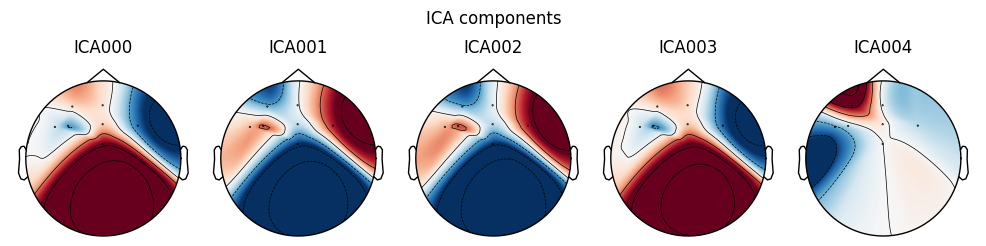

Creating RawArray with float64 data, n_channels=5, n_times=250
    Range : 0 ... 249 =      0.000 ...     0.996 secs
Ready.


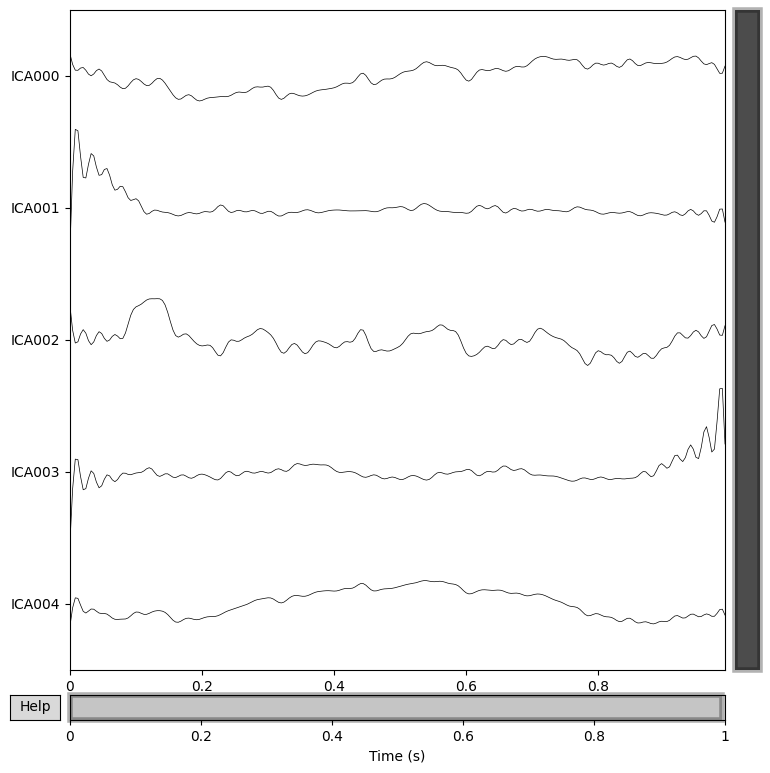

Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 2 ICA components
    Projecting back using 7 PCA components
Effective window size : 0.512 (s)
  Channel  Theta (4–7 Hz)  Alpha (8–12 Hz)  Beta (13–30 Hz)  Gamma (30–40 Hz)
0      Fz       47.426297         2.266240         1.862215          0.398819
1     FC3     1186.317671        60.508704        35.044349          6.804785
2     FC5      237.911379        11.814935         5.386045          1.493088
3      F3      214.828578        10.030468         4.460294          2.220759
4     FC4     2187.027876       113.193178        65.484861         12.516670
5     FCz      240.379083        12.712940         7.225671          1.360344
6      Cz     3627.920280       190.914710       114.067456         21.081079


<Figure size 1200x600 with 0 Axes>

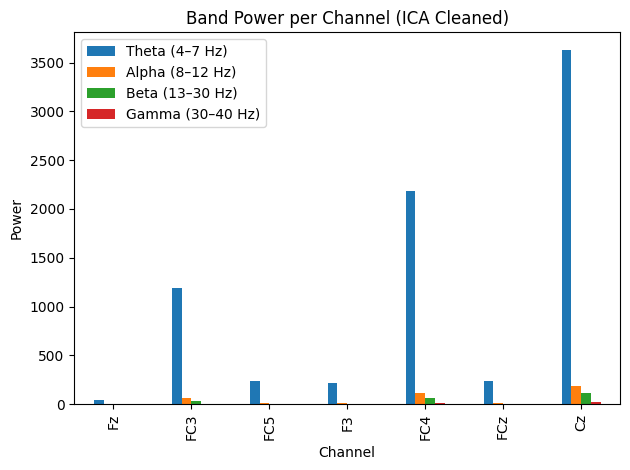

In [128]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# first_data: rows = samples, columns = 8 EEG channels
# 1. Clean and Load Data
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.7
df = df.dropna(thresh=threshold, axis=1)
df = df.interpolate(method='linear', limit=5, limit_direction='both')
df = df.fillna(method='bfill').fillna(method='ffill')

# 2. MNE Array Building
sfreq = 250
data = df.values.T  # shape: (n_channels, n_samples)

# Mapping --> make it less manual
ch_names = [
    "Fz",   # 1
    "FC3",   # 2
    "FC5",  # 3
    "F3",   # 4
    "FC4",   # 5
    "FCz",  # 6
    "Cz",  # 7
    #"F5"    # 8
]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# 3. ICA topography
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# 4. Filtering
# 1–40 Hz is a good compromise for ICA + PSD
raw.filter(1., 40., fir_design='firwin')
raw.notch_filter(60.)
raw.filter(l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming')
raw.set_eeg_reference('average')

# 5. ICA
ica = mne.preprocessing.ICA(
    n_components= 0.99999,
    random_state=97,
    max_iter='auto'
)
ica.fit(raw)

# # Inspect components:
ica.plot_components()      # scalp maps
ica.plot_sources(raw)      # time series

# After inspecting, set the components you want to remove:
ica.exclude = [0,1]  # don't know how to do this
raw_clean = ica.apply(raw.copy())

# 6. PSDs
psds, freqs = raw_clean.compute_psd(
    fmin=2,
    fmax=40,
    n_fft=128
).get_data(return_freqs=True)

# 7. Bandpower
def band_power(psds, freqs, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return psds[:, mask].mean(axis=1)

theta = band_power(psds, freqs, 4, 7)
alpha = band_power(psds, freqs, 8, 12)
beta  = band_power(psds, freqs, 13, 30)
gamma = band_power(psds, freqs, 30, 40)

# 8. Plotting
bands_df = pd.DataFrame({
    'Channel': ch_names,
    'Theta (4–7 Hz)': theta,
    'Alpha (8–12 Hz)': alpha,
    'Beta (13–30 Hz)': beta,
    'Gamma (30–40 Hz)': gamma
})

print(bands_df)

plt.figure(figsize=(12, 6))
bands_df.set_index('Channel').plot(kind='bar')
plt.ylabel('Power')
plt.title('Band Power per Channel (ICA Cleaned)')
plt.tight_layout()
plt.show()


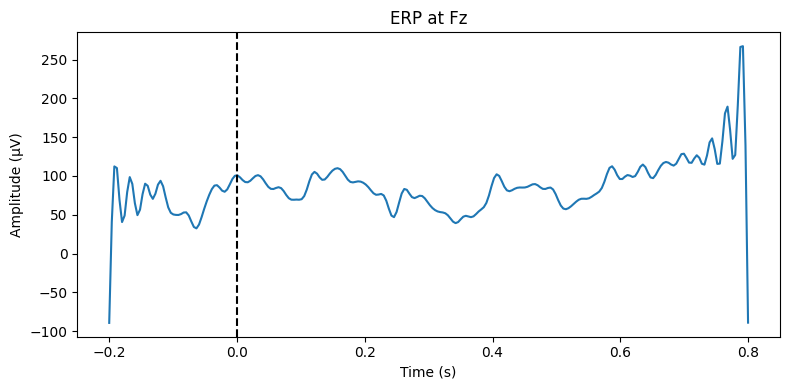

In [129]:
channel = "Fz"
idx = ch_names.index(channel)
erp = raw_clean.get_data()
times = np.linspace(-0.2, 0.8, erp[idx].shape[-1])

plt.figure(figsize=(8,4))
plt.plot(times, erp[idx])
plt.axvline(0, color='k', linestyle='--')
plt.title(f"ERP at {channel}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.tight_layout()
plt.show()


Not setting metadata
65 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)


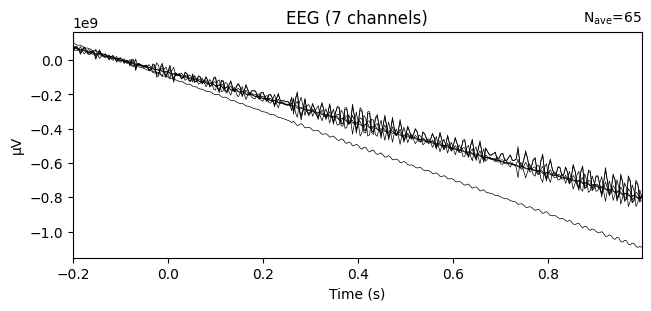

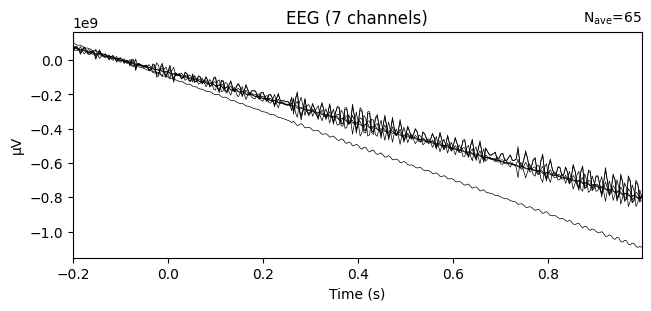

In [132]:
# stimulus locked ERP
stim_times = np.array(psychopy['LSL_Time']) - 898811.1682307
pre, post = 0.2, 1.0
sfreq = 250
tmin = -pre

epochs = []
for t in stim_times:
    mask = (eeg_df["Time"] >= (t - pre)) & (eeg_df["Time"] <= (t + post))
    win = eeg_df.loc[mask, [" Ch01"," Ch02"," Ch03"," Ch04"," Ch05"," Ch06"," Ch07"]].to_numpy().T
    if win.shape[1] == int((pre+post)*sfreq):
        epochs.append(win)

epochs = np.stack(epochs, axis=0)  # (n_epochs, 7, n_times)
info = mne.create_info(ch_names=["Ch01","Ch02","Ch03","Ch04","Ch05","Ch06","Ch07"],
                       sfreq=sfreq, ch_types="eeg")
epochs_mne = mne.EpochsArray(epochs, info, tmin=tmin)
epochs_mne.apply_baseline((None, 0))
evoked = epochs_mne.average()
evoked.plot()


In [96]:
raw_clean.get_data().shape

(7, 250)